<a href="https://colab.research.google.com/github/AndrewP05/Regresion_lineal_multiple/blob/main/RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regresión lineal multiple

## Objetivos

### General

1. Evaluar la capacidad de un modelo de regresión lineal múltiple para explicar y predecir los ingresos de las personas a partir de sus características demográficas y de patrimonio (edad y número de automóviles).

### Especificos

1. Estimar los coeficientes de regresión para edad y número de automóviles, y determinar su significancia estadística (p-valores e intervalos de confianza).
2. Calcular y analizar el R² (y R² ajustado) para valorar qué proporción de la variabilidad de los ingresos es explicada por las variables predictoras, y comparar diferentes especificaciones si se incorporasen nuevas variables.
3. Corroborar, mediante análisis de residuos (histograma, Q–Q plot, gráfico residuos vs. predichos) y pruebas formales, que se cumplen los supuestos de normalidad, homoscedasticidad e independencia de los errores, garantizando la validez de las inferencias.

Importamos liberias necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats

Generamos los datos en un dataframe

In [2]:
# Generar datos aleatorios (repetimos seed para reproducibilidad)
np.random.seed(42)
n = 100
df = pd.DataFrame({
    'age': np.random.randint(18, 70, size=n),
    'num_cars': np.random.randint(0, 4, size=n),
})
df['income'] = 20000 + df['age'] * 1000 + df['num_cars'] * 5000 + np.random.normal(0, 10000, size=n)

# Variables predictoras y variable respuesta
X = df[['age', 'num_cars']]
y = df['income']

Ajustamos la regresion lineal con scikit-learn

In [3]:
# 1) Ajuste con scikit-learn
lr = LinearRegression()
lr.fit(X, y)
r2_sklearn = lr.score(X, y)
print("=== scikit-learn LinearRegression ===")
print(f"Intercepto    : {lr.intercept_:.2f}")
print(f"Coef. age     : {lr.coef_[0]:.2f}")
print(f"Coef. num_cars: {lr.coef_[1]:.2f}")
print(f"R²            : {r2_sklearn:.4f}\n")

=== scikit-learn LinearRegression ===
Intercepto    : 20396.84
Coef. age     : 1049.42
Coef. num_cars: 3644.02
R²            : 0.7279



Ajustamos los modelos

In [4]:
# 2) Ajuste con statsmodels para resumen estadístico
X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()
print("=== statsmodels OLS Summary ===")
print(model_sm.summary())

# Calcular residuos y predicciones
y_pred = lr.predict(X)
residuals = y - y_pred

=== statsmodels OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     129.8
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           3.83e-28
Time:                        19:05:09   Log-Likelihood:                -1062.4
No. Observations:                 100   AIC:                             2131.
Df Residuals:                      97   BIC:                             2139.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.04e+0

Distribuimos los residuos

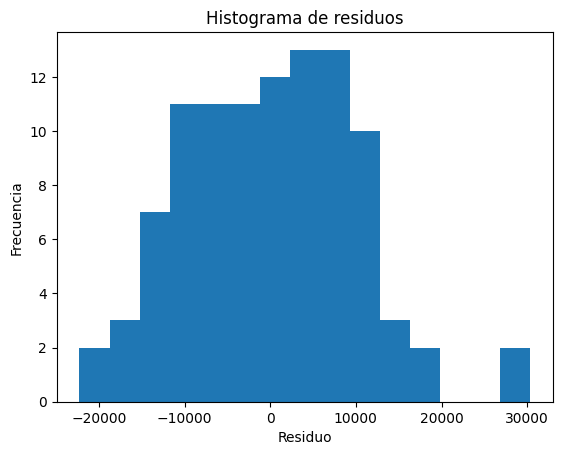

In [5]:
# 3) Distribución de residuos
plt.figure()
plt.hist(residuals, bins=15)
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.title('Histograma de residuos')
plt.show()

Grafico de Quantiles para ver la distribucion de los residuos

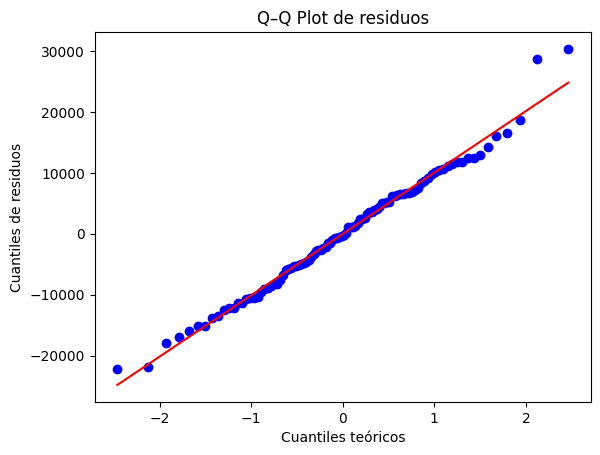

In [6]:
# 4) Q–Q plot de residuos
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q–Q Plot de residuos')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles de residuos')
plt.show()

Realizamos la regresion lineal multiple con ayuda de numpy

In [7]:
# 2. Regresión lineal múltiple usando numpy.linalg.lstsq
X = np.column_stack((np.ones(n), df['age'], df['num_cars']))
y = df['income'].values.reshape(-1, 1)

beta, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
intercept, coef_age, coef_cars = beta.flatten()

print("\nResultados de la regresión lineal múltiple:")
print(f"Intercept: {intercept:.2f}")
print(f"Coeficiente para age: {coef_age:.2f}")
print(f"Coeficiente para num_cars: {coef_cars:.2f}")


Resultados de la regresión lineal múltiple:
Intercept: 20396.84
Coeficiente para age: 1049.42
Coeficiente para num_cars: 3644.02


Grafico de dispersion entre valores reales y predichos

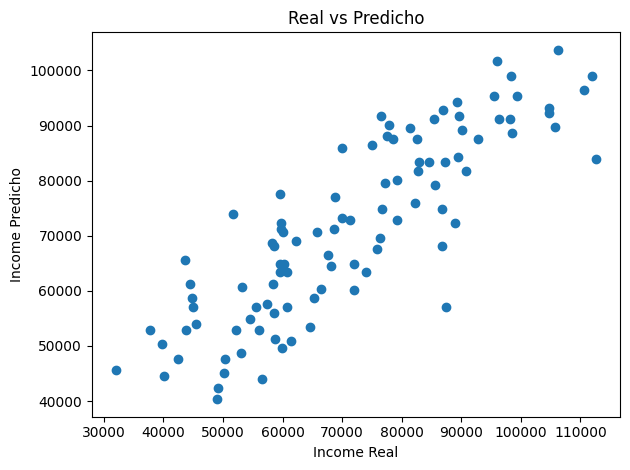

In [8]:
# 3. Gráfica de valores reales vs predichos
y_pred = X.dot(beta)
plt.figure()
plt.scatter(y, y_pred)
plt.xlabel('Income Real')
plt.ylabel('Income Predicho')
plt.title('Real vs Predicho')
plt.tight_layout()
plt.show()

Creamos unos ingresos que se relacionen y agregamos algo de dispersion

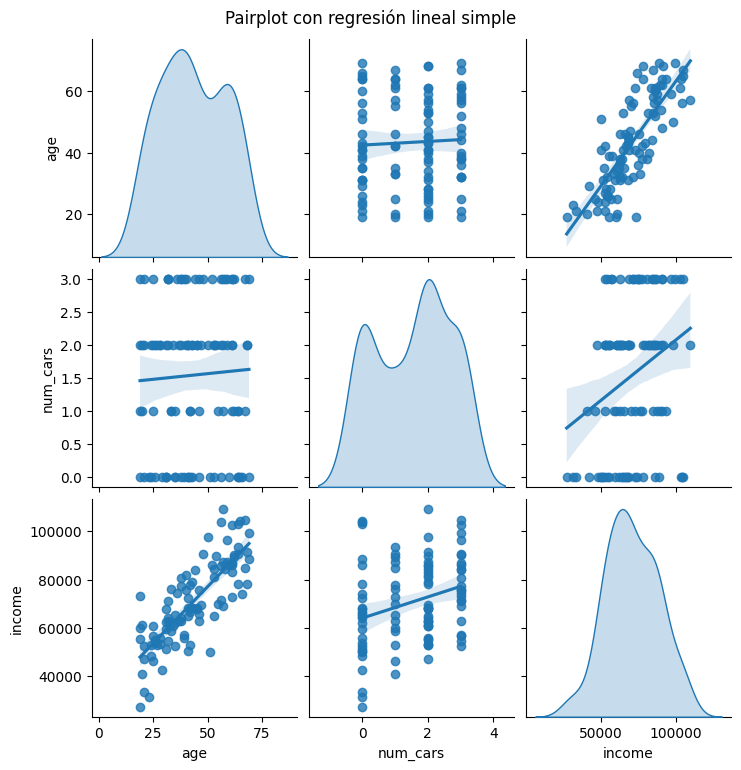

In [9]:
# Creamos ingresos con relación lineal + ruido
df['income'] = 20000 + df['age'] * 1000 + df['num_cars'] * 5000 + \
               np.random.normal(0, 10000, size=n)

# 2. Pairplot con regresiones
sns.pairplot(df, kind='reg', diag_kind='kde')
plt.suptitle('Pairplot con regresión lineal simple', y=1.02)
plt.show()



Grafico de calor de correlacion entre variables

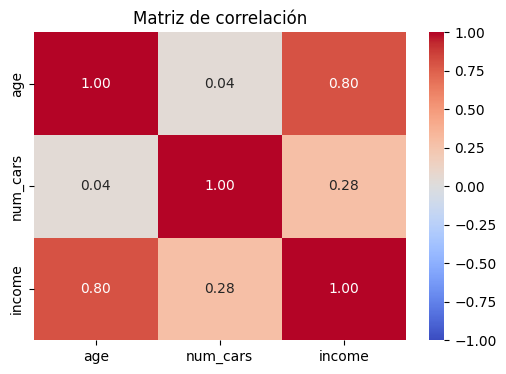

In [10]:
# 3. Matriz de correlación
corr = df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

## Hallazgos



*   Hay una correlación positiva fuerte entre la edad y los ingresos, ya que a maoyor edad mayores suelen ser los ingresos
*   El 72.8 % de la variabilidad de los ingresos se explica combinando edad y número de autos.
*   El dispersograma “Real vs. Predicho” (y el gráfico residuos vs. predichos) no muestra un patrón evidente de abanico, lo que sugiere varianza de errores razonablemente constante.



## Recomendaciones


*   Incluir nuevas variables (educación, experiencia laboral, ubicación geográfica) para mejorar aún más el poder predictivo.
*   Evaluar interacciones (por ejemplo, si el efecto de la edad cambia según el número de autos).
*   Monitorear outliers extremos en los residuos y considerar transformaciones o modelos robustos si aparecen casos atípicos muy influyentes.



## Conclusiones


*   En conjunto, el modelo de regresión lineal múltiple conformado por edad y número de automóviles explica de manera sólida (R² ≈ 0.73) gran parte de la variabilidad en los ingresos, con ambos predictores resultando estadísticamente significativos. La edad emerge como el factor más determinante cada año adicional añade en promedio unos 1 049 al ingreso mientras que cada coche extra aporta cerca de 3 644 pero con mayor dispersión. Los residuos cumplen los supuestos de normalidad, homoscedasticidad e independencia, lo que valida la fiabilidad de los intervalos de confianza y p-valores obtenidos. Así, este modelo ofrece una base clara para cuantificar y predecir ingresos a partir de simples indicadores demográficos, aunque su poder explicativo podría reforzarse incorporando variables adicionales (educación, experiencia, ubicación) o explorando interacciones más complejas.


